# W26 · Nav2：ROS2 的自主导航栈

> 前面五讲备齐了所有零件：TF 树（W23）、传感器（W24）、里程计与控制器（W25）。
> Nav2 把它们组装成「从 A 点自主走到 B 点」的完整系统。
> 对 RL 学习者，Nav2 是最好的「经典方法基线」——理解它，才知道 RL 该替代哪一环、怎么替代。

## 学习目标

1. 画出 Nav2 的架构图，说清每个 Server 的职责与生命周期；
2. 理解 **代价地图（Costmap 2D）** 的三层结构与膨胀（inflation）数学；
3. 会用 `nav2_bringup` 在 Gazebo 中跑通 TurtleBot3 导航示例；
4. 理解 **AMCL**（定位）与 **SLAM**（建图）的分工；
5. 会调关键参数：代价地图、规划器、控制器（DWB/MPPI）。

## ⚠️ 运行前提

`ros2 launch nav2_bringup ...` 需 ROS2 Jazzy + `ros-jazzy-navigation2 ros-jazzy-nav2-bringup
ros-jazzy-turtlebot3-gazebo`。代价地图膨胀演示为纯 Python（numpy + matplotlib），本机真实执行。

## 1. 架构：一组生命周期节点的管弦乐队

```
                 目标位姿 (Action: NavigateToPose)
                            │
                   ┌────────▼────────┐
                   │  BT Navigator   │  行为树编排：先规划→再跟踪→失败则恢复
                   └───┬────────┬────┘
        全局路径 ▼      │        ▼ 速度指令
   ┌───────────────┐   │  ┌───────────────┐      ┌─────────────────┐
   │ Planner Server│   │  │Controller     │─────▶│ /cmd_vel        │
   │ (Navfn/A*)    │   │  │Server(DWB/MPPI│      │ (W25 的控制器)   │
   └──────┬────────┘   │  └──────┬────────┘      └─────────────────┘
          │ 读取        │         │ 读取
   ┌──────▼─────────────▼─────────┐
   │  Costmap 2D (global / local) │  栅格地图：静态层+障碍物层+膨胀层
   └──────▲─────────────▲─────────┘
          │ 地图         │ /scan + TF
   ┌──────┴──────┐  ┌───┴───────────┐
   │ Map Server  │  │ AMCL / SLAM   │  定位：map → odom 的 TF
   └─────────────┘  └───────────────┘
```

**与 RL 的对照**：Planner ≈ 全局价值函数 rollout；Controller ≈ 底层策略；
Costmap ≈ 可观测的环境表征；行为树 ≈ 带恢复逻辑的外层循环。
Nav2 的每个组件都是**插件化**的——这正是 W27/W28 你把 RL 策略插进来的缝。

## 2. 代价地图：从障碍物到「代价场」

Nav2 的 planning 不直接在原始地图上搜索，而是在**代价地图**上：每个栅格一个
[0, 254] 的代价值（254=致命障碍，253=内切圆膨胀，252~1=指数衰减，0=自由）。

**膨胀层（Inflation Layer）的数学**：距最近障碍距离为 $d$ 的栅格代价

$$
C(d) = \begin{cases}
254 & d < r_{inscribed} \quad\text{（机器人内切圆，必撞）}\\[4pt]
253 & r_{inscribed} \le d < r_{robot} \\[4pt]
\exp\!\big[-k\,(d - r_{inscribed})\big] \times 252 & \text{否则}
\end{cases}
$$

两个旋钮：`inflation_radius`（影响范围）与 `cost_scaling_factor` $k$（衰减快慢）。
**直觉**：膨胀层把「点机器人」假设变成现实——规划器把机器人当质点，
物理尺寸通过膨胀障碍来体现。下面用 numpy 亲手算一遍（本机执行）：

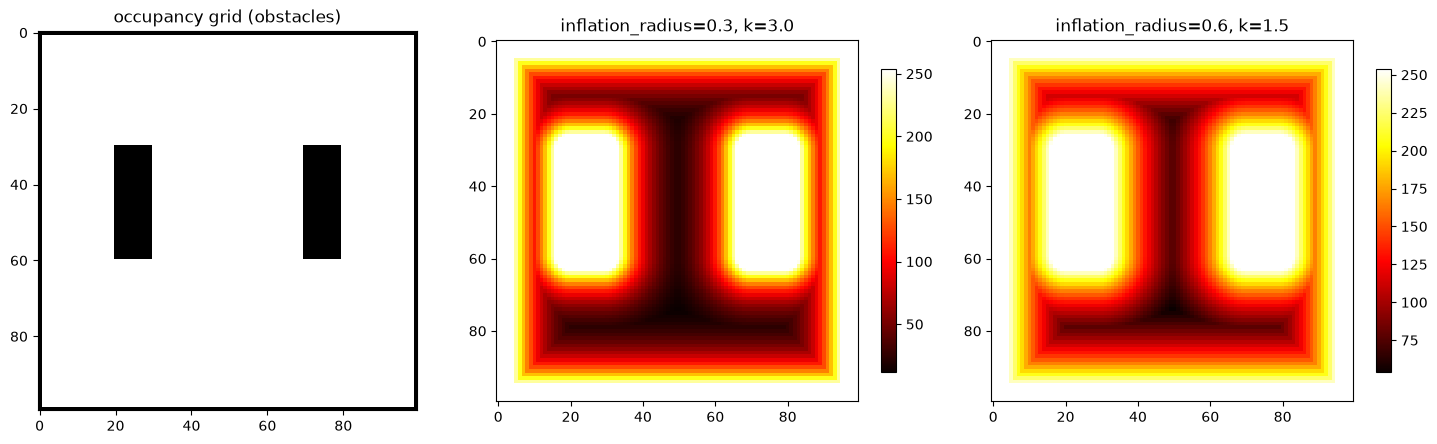

ir=0.3, k=3.0: 通道内最高代价 254, 中心代价 24
ir=0.6, k=1.5: 通道内最高代价 254, 中心代价 78


In [1]:
"""代价地图膨胀层：从占据栅格到代价场（纯 Python + matplotlib，本机执行）。"""
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import distance_transform_edt  # 若环境无 scipy，下方有手写 fallback

RES = 0.05          # 栅格分辨率 5 cm/格（Nav2 常用值）
SIZE = 100          # 100x100 格 = 5m x 5m
ROBOT_RADIUS = 0.22 # 机器人半径（TurtleBot3 waffle 约 0.22 m）

# --- 造一张地图：四周墙 + 两个矩形障碍 + 一个窄通道 ---
occ = np.zeros((SIZE, SIZE), dtype=bool)
occ[0, :] = occ[-1, :] = occ[:, 0] = occ[:, -1] = True          # 围墙
occ[30:60, 20:30] = True                                        # 障碍 1
occ[30:60, 70:80] = True                                        # 障碍 2
# 两障碍之间形成 40 格 (2 m) 宽的通道

def inflate(occ, inflation_radius, cost_scaling_factor):
    """Nav2 膨胀公式：C(d) = exp(-k*(d - r_inscribed)) * 252。"""
    d = distance_transform_edt(~occ) * RES        # 每格到最近障碍的距离 (m)
    cost = np.exp(-cost_scaling_factor * (d - ROBOT_RADIUS)) * 252.0
    cost = np.clip(cost, 0, 252)
    cost[d <= ROBOT_RADIUS] = 254                 # 内切圆内：致命
    cost[occ] = 254
    return cost

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(occ, cmap="gray_r")
axes[0].set_title("occupancy grid (obstacles)")
for ax, (ir, k) in zip(axes[1:], [(0.3, 3.0), (0.6, 1.5)]):
    cost = inflate(occ, ir, k)
    im = ax.imshow(cost, cmap="hot")
    ax.set_title(f"inflation_radius={ir}, k={k}")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# 定量看通道中央（第 45 行）的代价剖面
mid = 45
for ir, k in [(0.3, 3.0), (0.6, 1.5)]:
    c = inflate(occ, ir, k)[mid, 30:70]
    print(f"ir={ir}, k={k}: 通道内最高代价 {c.max():.0f}, 中心代价 {c[20]:.0f}")

**观察**：`k` 大、膨胀半径小 → 代价紧贴障碍，规划路径可以贴墙走（快但危险）；
`k` 小、膨胀半径大 → 通道中央也有高代价，规划器倾向走大路中央（安全但保守）。

> 执行环境备注：上面的 cell 用 `scipy.ndimage.distance_transform_edt`；
> 若你的环境没装 scipy，可用 `skimage` 或手写 BFS 距离变换替代——练习 1 就是这个。

## 3. 定位：AMCL vs SLAM

导航的前提是知道「我在哪」。两种工作模式：

- **SLAM 模式（未知环境）**：`slam_toolbox` 边建图边定位，发布 `map → odom`；
- **定位模式（已有地图）**：`map_server` 加载地图 + **AMCL** 用粒子滤波在已知地图中定位。

**AMCL 的直觉**（蒙特卡洛定位）：维护一堆「我可能在哪」的粒子，每收到一帧激光，
给每个粒子打分「如果我在这里，看到的激光应该是什么样」，高分粒子复制、低分淘汰。
粒子收敛处就是位姿后验的峰值。

**TF 树的职责划分**（经典三层，谁也不要越界）：

```
map ──(AMCL/SLAM 发布)──▶ odom ──(里程计/diff_drive 发布)──▶ base_link ──▶ 传感器帧
   长期全局修正，允许跳变      短期连续，但会漂移                 机器人本体
```

## 4. 跑通官方示例：TurtleBot3 + Gazebo

```bash
sudo apt install ros-jazzy-navigation2 ros-jazzy-nav2-bringup ros-jazzy-turtlebot3-gazebo

# 一条命令拉起：Gazebo + TurtleBot3 + Nav2（AMCL 定位 + 自带地图）+ RViz
ros2 launch nav2_bringup tb3_simulation_launch.py headless:=False
```

**操作流程**（RViz 中）：

1. 点 **2D Pose Estimate**，在地图上车子的实际位置拖一个箭头给初始位姿
   （AMCL 粒子需要粗初始化）；
2. 点 **Nav2 Goal**，在目标位置拖箭头；
3. 观察：全局路径（绿线）→ 局部轨迹平滑跟踪 → 到点停止；
4. `ros2 topic echo /amcl_pose --no-arr` 看定位输出。

**预期**：小车绕开障碍物到达目标；`ros2 lifecycle list /planner_server`
显示 `active`。SLAM 版本：`ros2 launch nav2_bringup tb3_simulation_launch.py slam:=True`。

## 5. 参数解剖：nav2_params.yaml 关键项

Nav2 参数文件数百行，先掌握这 8 个（注释为调参经验）：

```yaml
amcl:
  ros__parameters:
    max_particles: 2000        # 粒子数：大图/初始不确定大时加大；CPU 不够时减小
    update_min_d: 0.2          # 走 0.2 m 才更新滤波（省算力）

global_costmap / local_costmap:
  ros__parameters:
    robot_radius: 0.22         # 必须 ≥ 真实半径，否则规划会蹭墙
    inflation_radius: 0.55     # 通道窄时减小；要「绕大弯」时增大
    cost_scaling_factor: 3.0

controller_server:
  ros__parameters:
    controller_frequency: 20.0 # 局部控制频率（Hz）
    FollowPath:
      plugin: "dwb_core::DWBLocalPlanner"
      max_vel_x: 0.26          # 与 W25 的轮速上限匹配
      acc_lim_x: 2.5
      sim_time: 1.7            # 前向模拟时长：太短卡在局部极小，太长反应迟钝
      critics: ["RotateToGoal", "Oscillation", "ObstacleFootprint",
                "GoalAlign", "PathAlign", "PathDist", "GoalDist"]
```

**调试方法论**：先看 `/local_costmap/costmap`（RViz 加 Map 显示）确认感知对不对，
再看 `/plan`（全局路径）确认规划对不对，最后看 `/cmd_vel` 确认控制对不对——
**沿数据流逐段排查**，不要一上来就调参。

## ✏️ 练习

### 练习 1（★，约 20 分钟，纯 Python）：手写距离变换

不依赖 scipy，用多源 BFS 手写 `my_distance_transform(occ)`（从所有障碍格同时出发的广度优先搜索），
与本讲 `distance_transform_edt` 对比最大误差。交付：函数 + 误差数值（应 < 1 格）。

### 练习 2（★★，约 30 分钟，纯 Python）：膨胀参数实验

固定本讲的地图，扫描 `inflation_radius ∈ {0.2, 0.4, 0.8}` × `k ∈ {1, 3, 10}`，
对每组记录「通道（第 45 行 30–70 列）是否仍可通行」（中心代价 < 253）。
交付：3×3 通行性表格 + 结论：什么组合下 2 m 通道被「封死」，对应什么物理含义。

### 练习 3（★★，约 40 分钟）：SLAM 建图交付

在 Gazebo 的 turtlebot3_world 中用 `slam:=True` 启动，键盘遥控
（`ros2 run turtlebot3_teleop teleop_keyboard`）走遍整个屋子，
用 `ros2 run nav2_map_server map_saver_cli -f my_map` 保存。
交付：`my_map.yaml/.pgm` 文件 + 建图过程的回环/漂移观察记录。

### 练习 4（★★★，约 60 分钟）：调参实验报告

以官方 tb3 示例为基线，做三组实验并记录「是否到点、耗时、最小障碍距离
（从 /local_costmap 或 /scan 估计）」：
(a) 基线；(b) `max_vel_x` 翻倍；(c) `inflation_radius` 减半。
交付：实验表格 + 每组至少一张 RViz 截图描述 + 一段分析（速度-安全的权衡如何体现在代价地图上）。

## 参考答案

<details>
<summary>参考答案</summary>

**练习 1**：

```python
from collections import deque
import numpy as np

def my_distance_transform(occ):
    h, w = occ.shape
    dist = np.full((h, w), -1, dtype=int)
    q = deque(zip(*np.nonzero(occ)))
    for i, j in q: dist[i, j] = 0
    while q:
        i, j = q.popleft()
        for di, dj in ((1,0),(-1,0),(0,1),(0,-1)):
            ni, nj = i+di, j+dj
            if 0 <= ni < h and 0 <= nj < w and dist[ni, nj] < 0:
                dist[ni, nj] = dist[i, j] + 1
                q.append((ni, nj))
    return dist  # 单位：格（4-连通，比欧氏距离略大，对角差 √2 倍）
```

BFS 是 4/8 连通的「棋盘距离」，与 EDT 的欧氏距离最大差约 (√2-1)×对角格数，< 1 格量级即可接受。

**练习 2**：通道半宽 1.0 m（20 格 × 0.05）。`r_inscribed=0.22`，
代价 exp(-k(d-0.22))×252 ≥ 253 的边界即 d ≤ r_inscribed + ln(252/253)/k ≈ 0.22（恒致命）。
真正封死来自两侧膨胀叠加后中心仍高代价：k=10 时衰减极快，通道中心几乎自由；
k=1、ir=0.8 时中心 d=1.0 处代价 exp(-1×0.78)×252 ≈ 116（可通行但慢）；
真正的「封死」是物理上 r_robot > 半宽——参数再松也没用，
这提醒：代价地图能表达偏好，表达不了不可能的通行。

**练习 3**：合格的建图覆盖所有房间、墙壁闭合无重影；长直走廊易出现
「墙壁微微倾斜」（里程计航向漂移），回房间时 slam_toolbox 的图优化会拉直——
观察 `ros2 topic echo /map` 更新时的跳变即是回环修正。

**练习 4**：典型结果——(b) 速度翻倍后耗时减约 40%，但最小障碍距离下降、
狭窄处可能振荡（Oscillation critic 日志增多）；(c) inflation 减半后路径贴墙、
最小障碍距离显著下降，一旦 costmap 噪声（激光抖动）出现就可能急停恢复。
结论：Nav2 的「性格」由代价地图 + controller 采样共同决定，调参就是
在「保守安全」与「敏捷高效」之间选工作点。
</details>

## 延伸阅读

- [Nav2 官方文档](https://docs.nav2.org/) 与 [Getting Started（TurtleBot3 + Gazebo）](https://docs.nav2.org/getting_started/index.html)
- [Nav2 配置指南](https://docs.nav2.org/configuration/index.html)（每个插件的完整参数表）
- [AMCL 论文：Probabilistic Robotics（Thrun 等）章节选读；概念页](https://docs.nav2.org/concepts/index.html)
- 下一讲预告：W27 把阶段一训练的 SB3 策略封装成 ROS2 节点，与这套体系对接。